In [10]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 08 – Detection Sandbox

Interaktív összehasonlító labor: ROI-extrakciós stratégiák, Nut-detektálás és Bund-detektálás.

---

## Pipeline Hierarchia — a lépések sorrendje

```
Eredeti kép (RAW)
    │
    ▼  1. PREPROCESSING  (src/preprocess.py)
    │     CLAHE → Blur → Normalize
    │     ⚠  MediaPipe landmarkokat az EREDETI képen futtatjuk (CLAHE rontja a MP telj.)
    │
    ▼  2. SEGMENTATION / MASKING  (src/hand_landmark.py)
    │     Finger-maszk: az ujjak éleit elnyomja a Canny előtt
    │     Anchor: a csukló/tenyér alapján becsüli a nyak irányát
    │
    ▼  3. ROI EXTRACTION  (src/geometry.py: step1..step6_warp)
    │     Canny → Hough → Nyakirány → Outer-edges → Trapézoid → Homography warp
    │     Kimenet: kanonikus kép (600 × 80 px)
    │
    ▼  4. NUT DETECTION  (src/geometry.py: step6b_find_nut)
    │     *** A NUT KERESÉS A ROI UTÁN FUT ***
    │     Sobel-X gradiens-profil → bal/jobb oldal csúcsdetektálás
    │     Ha a Nut-x a kanonikus képen kívülre esne:
    │       → step6c_trim_to_nut visszaveti az orig. képbe (H_inv)
    │       → és újra warpolja a Nut-tól a kép széléig
    │     Így a Nut sosem esik "kívülre": a warp mindig tartalmazza.
    │
    ▼  5. FRET DETECTION  (src/fretboard.py: FretDetectorInterface)
          GeometricFretDetector : Hough-alapú bundvonalak
          IntensityFretDetector : Sobel-X csúcsdetektálás (default)
          → step8_fit_fret_rule: 17.817-es szabály illesztés
```

### Nut vs. ROI — mi jön előbb?

**A ROI jön elsőként.** A Nut-keresés a kanonikus (600×80 px) képen fut, amely a warp
után áll elő. Ezért ha a ROI rosszul lett meghatározva (pl. a trapézoid kihagyja a Nut-ot),
a Nut-detektálás sem tud helyes eredményt adni.

A `step6c_trim_to_nut` pont ezt kezeli: ha a Nut detektálva lett a kanonikus képen,
visszavetíti a trapézoid sarkait az eredeti képbe, majd újra warpolja — ez garantálja, hogy
a végső kanonikus kép bal vagy jobb szélén ott van a Nut.

In [11]:
# ══════════════════════════════════════════════════════════════════
#  SANDBOX PARAMÉTEREK — itt módosítsd a kísérletekhez
# ══════════════════════════════════════════════════════════════════

# Vizuális
FIG_DPI          = 120
FIG_WIDE         = (16, 4)    # széles összehasonlító ábrákhoz
FIG_SQUARE       = (14, 10)   # négyzetes, több panel
FIG_NUT_ZOOM     = (12, 5)    # nut zoom ábra

# Preprocessing override (None = src/config.py alapértelmezés)
SANDBOX_CLAHE_CLIP   = 2.0    # CLAHE clipLimit
SANDBOX_BLUR_ENABLED = False   # pipeline-szintű Gaussian blur

# IntensityFretDetector paraméterek
PEAK_HEIGHT     = 0.12
PEAK_DISTANCE   = 7
PEAK_PROMINENCE = 0.06
PEAK_MAX_WIDTH  = 14.0
SMOOTH_SIGMA    = 1.5

# Nut-keresési sáv (kanonikus képen, px)
NUT_HAND_MARGIN = 10

# Kimeneti mappa
from pathlib import Path
OUTPUT_DIR = Path("..") / "output" / "08_detection_sandbox"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output: {OUTPUT_DIR.resolve()}")

Output: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/08_detection_sandbox


Osztály : D
Fájl    : IMG_20251102_023952.jpg
Méret   : 4640×3488 px


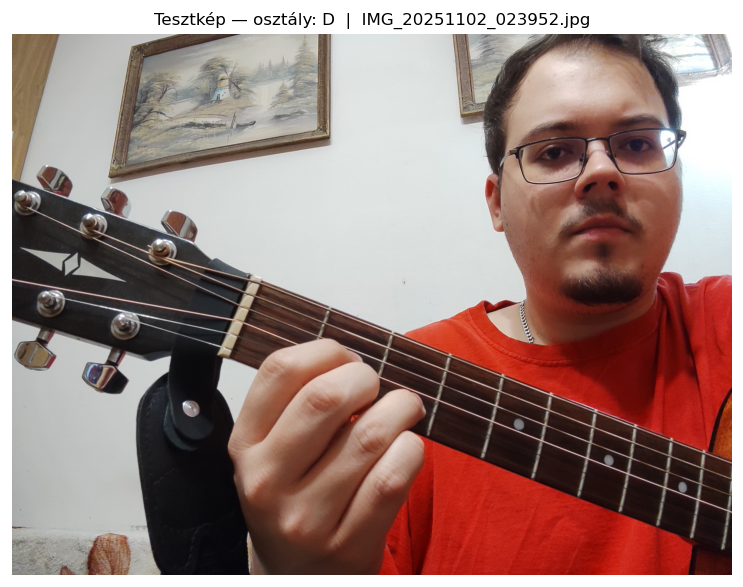

In [12]:
# ══════════════════════════════════════════════════════════════════
#  Adatbetöltés — tesztkép kiválasztása
# ══════════════════════════════════════════════════════════════════
from src.dataset import load_manifest
from src.geometry import bgr2rgb, load_image_bgr
from src.config import PATHS

manifest = load_manifest()

# Lehetőleg B vagy F osztály: a nut jól látszik
# random_state módosításával más kép választható
RANDOM_STATE = 42
TARGET_CLASS = None   # None = bármely osztály; pl. "B" vagy "F"

if TARGET_CLASS:
    pool = manifest[manifest["class"] == TARGET_CLASS]
else:
    pool = manifest

sample = pool.sample(1, random_state=RANDOM_STATE).iloc[0]
IMG_PATH = sample["path"]
img_bgr  = load_image_bgr(IMG_PATH)

print(f"Osztály : {sample['class']}")
print(f"Fájl    : {IMG_PATH.name}")
print(f"Méret   : {img_bgr.shape[1]}×{img_bgr.shape[0]} px")

# Előnézet
fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=FIG_DPI)
ax.imshow(bgr2rgb(img_bgr))
ax.set_title(f"Tesztkép — osztály: {sample['class']}  |  {IMG_PATH.name}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

---

## 1. ROI Algoritmusok Összehasonlítása

Három stratégia egymás mellett:

| Stratégia | Leírás | Erősség | Gyengeség |
|---|---|---|---|
| **Old Stable** | Csak Canny + Hough + geometrikus trapézoid | Gyors, MediaPipe nélkül is fut | Kéz-okklúzióra érzékeny |
| **MediaPipe Guided** | V14 full pipeline: anchor + finger mask + wrist clamp | Robusztus kézkezelés | MediaPipe szükséges |
| **Intensity-based** | Sor-projekciós Sobel energia → fretboard sáv keresése | Nem függ Hough paramétercsnáktól | Perspektívakorrekció nélküli crop |

In [13]:
# ══════════════════════════════════════════════════════════════════
#  ROI Stratégiák implementálása
# ══════════════════════════════════════════════════════════════════
from src.geometry import (
    step1_canny, step2_hough, step3_neck_angle, step4_split_lines,
    step5_outer_edges, step6_trapezoid, step6_warp,
)
from src.fretboard import run_v14_pipeline
from src.preprocess import ImagePreprocessor
from src.config import PREPROCESSING_CONFIG


def roi_old_stable(img_bgr: np.ndarray) -> dict | None:
    """Old Stable: geometrikus Hough, nincs MediaPipe.

    Pontosan a V14 előtti megközelítés: Canny → Hough → neck_angle
    (anchor nélkül) → split → outer_edges → trapézoid → warp.
    Nincs finger-maszk, nincs anchor-korrekció.
    """
    edges = step1_canny(img_bgr)
    lines = step2_hough(img_bgr, edges)
    if not lines:
        return None
    neck  = step3_neck_angle(lines)
    split = step4_split_lines(lines, neck["angle_deg"])
    if not split["long_lines"]:
        return None
    edge_info = step5_outer_edges(split["long_lines"], neck["angle_deg"])
    if edge_info is None:
        return None
    trap = step6_trapezoid(img_bgr, edge_info)
    if trap is None:
        return None
    H, H_inv, canon = step6_warp(img_bgr, trap["corners_px"])
    return {
        "label":    "Old Stable",
        "img":      img_bgr,
        "edges":    edges,
        "trap":     trap,
        "canon":    canon,
        "H":        H,
        "H_inv":    H_inv,
        "ok":       True,
    }


def roi_mediapipe_guided(img_path, preprocessor=None) -> dict:
    """MediaPipe Guided: teljes V14 pipeline (anchor + finger mask + nut-trim)."""
    entry = {"path": img_path, "class": "?"}
    result = run_v14_pipeline(entry, preprocessor=preprocessor)
    result["label"] = "MediaPipe Guided"
    return result


def roi_intensity_based(img_bgr: np.ndarray,
                        row_frac: float = 0.3,
                        smooth_sigma: float = 5.0) -> dict | None:
    """Intensity-based: sor-projekciós Sobel energia alapján keresi a fretboard sávot.

    Nem használ Hough-transzformációt. A vízszintes gradiens-energia
    sor-összege megmutatja, melyik sor tartalmaz sok vertikális élt (bundokat).
    Kimenet: téglalap crop (nincs perspektívakorrekció), 600×80-ra átméretezve.
    """
    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Vízszintes Sobel (detektálja a vertikális éleket = bundok)
    sx = np.abs(cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3))
    row_energy = sx.mean(axis=1)                       # (H,)
    row_smooth = gaussian_filter1d(row_energy, sigma=smooth_sigma)

    # Fretboard sáv: sorok ahol a gradiens > max * row_frac
    threshold = row_smooth.max() * row_frac
    active_rows = np.where(row_smooth > threshold)[0]
    if len(active_rows) < 3:
        return None

    # Padding
    band_h = active_rows[-1] - active_rows[0]
    pad    = max(int(band_h * 0.15), 5)
    y1 = max(0,     active_rows[0]  - pad)
    y2 = min(h - 1, active_rows[-1] + pad)

    crop = img_bgr[y1:y2, :].copy()

    # Canonical-méretűre hozás (600×80) – csak aspect-stretch, nincs warp
    from src.constants import CANONICAL_W, CANONICAL_H
    canon = cv2.resize(crop, (CANONICAL_W, CANONICAL_H))

    return {
        "label":       "Intensity-based",
        "img":         img_bgr,
        "row_energy":  row_smooth,
        "y1":          y1,
        "y2":          y2,
        "crop":        crop,
        "canon":       canon,
        "ok":          True,
    }


# ── Futtatás ─────────────────────────────────────────────────────────────────
print("[1/3] Old Stable...")
res_old  = roi_old_stable(img_bgr)

print("[2/3] MediaPipe Guided...")
sandbox_prep_cfg = {**PREPROCESSING_CONFIG,
                    "clahe_clip_limit": SANDBOX_CLAHE_CLIP,
                    "blur_enabled":     SANDBOX_BLUR_ENABLED}
prep = ImagePreprocessor(config=sandbox_prep_cfg)
res_mp   = roi_mediapipe_guided(IMG_PATH, preprocessor=prep)

print("[3/3] Intensity-based...")
res_int  = roi_intensity_based(img_bgr)

for r, name in [(res_old, "Old Stable"), (res_mp, "MediaPipe"), (res_int, "Intensity")]:
    ok  = r.get("ok", False) if r else False
    why = r.get("invalid_reason") if r else "None result"
    print(f"  {name:20s}  ok={ok}  {why or ''}")

[1/3] Old Stable...
  [outer_edges_v9] vonalak: 11 | bal outlier: nem | jobb outlier: nem
  [outer_edges_v9] Bal oldal bővítve: -89.1px
  [outer_edges_v9] Jobb oldal bővítve: +89.1px
  [outer_edges_v9] szétválasztás: 178.2px (klaszter: 297.0px | bővítés: 89.1px)
  [trapezoid_v9] span=4274.0px | w_start=178.2px | w_end=178.2px | area=792112px²
[2/3] MediaPipe Guided...
  [outer_edges_v9] vonalak: 9 | bal outlier: nem | jobb outlier: igen
  [outer_edges_v9] Bal oldal bővítve: -87.9px
  [outer_edges_v9] szétválasztás: 422.7px (klaszter: 293.1px | bővítés: 87.9px)
  [trapezoid_v9] span=1979.9px | w_start=422.7px | w_end=422.7px | area=870344px²
  [nut_detect_v12] side_hint=left | median=1148 | peak=10757 | ratio=9.37 | fwhm=21.0px
  [nut_detect_v12] nut találat: left @ x=175px (fwhm=21.0px)
  [fret_fit v11] nut-anchored | scale=4317.1px | cov=100% (3/3)
  [fret_fit v11] nut-anchored | scale=4317.1px | cov=100% (3/3)
[3/3] Intensity-based...
  Old Stable            ok=True  
  MediaPipe    

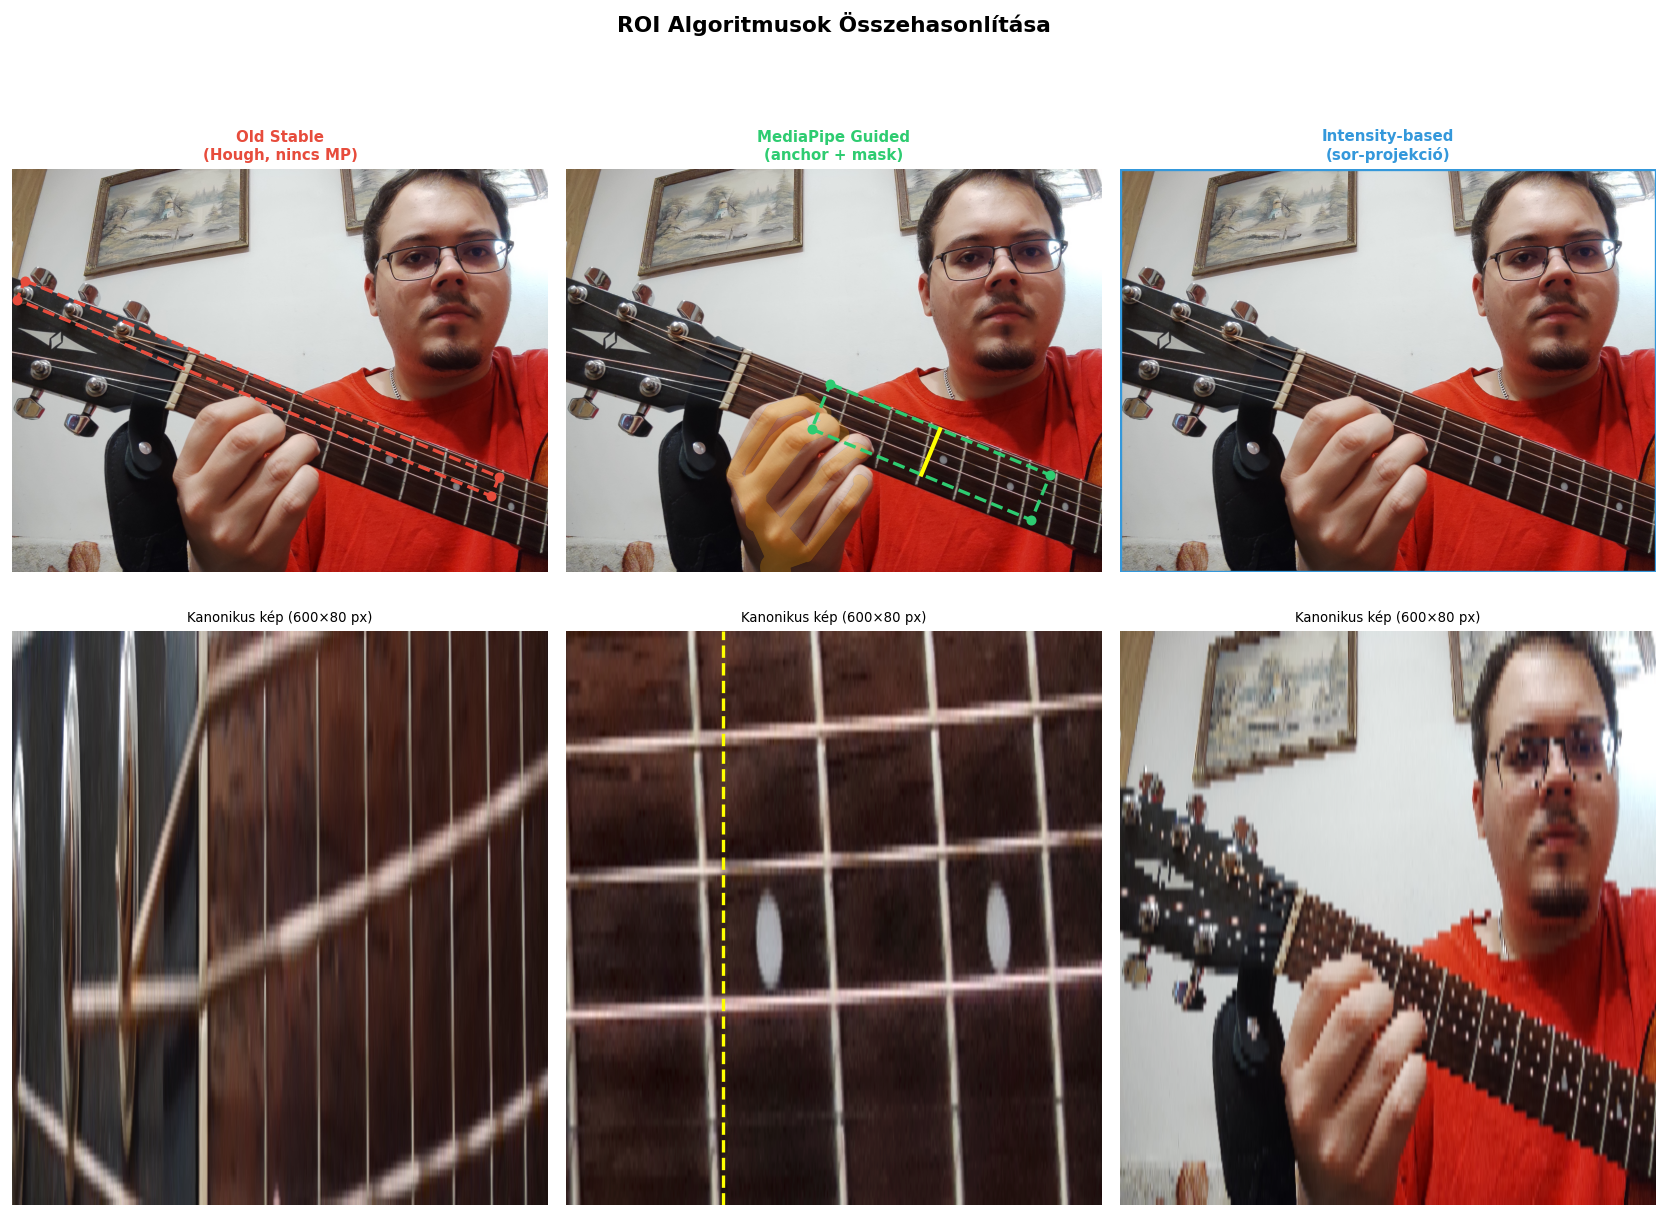

Ábra: ../output/08_detection_sandbox/01_roi_comparison.png


In [14]:
# ══════════════════════════════════════════════════════════════════
#  ROI Összehasonlítás vizualizáció
#  Felső sor: eredeti kép + ROI overlay
#  Alsó sor:  kanonikus (warped) kép
# ══════════════════════════════════════════════════════════════════

strategies = [
    (res_old, "Old Stable\n(Hough, nincs MP)",   "#e74c3c"),
    (res_mp,  "MediaPipe Guided\n(anchor + mask)", "#2ecc71"),
    (res_int, "Intensity-based\n(sor-projekció)",  "#3498db"),
]

fig, axes = plt.subplots(2, 3, figsize=FIG_SQUARE, dpi=FIG_DPI)
fig.suptitle("ROI Algoritmusok Összehasonlítása", fontsize=13, fontweight="bold", y=1.01)

for col, (res, label, color) in enumerate(strategies):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    # ─── Felső panel: eredeti + overlay ───────────────────────────
    display = bgr2rgb(img_bgr).copy()
    ax_top.imshow(display)
    ax_top.set_title(label, fontsize=9, color=color, fontweight="bold")
    ax_top.axis("off")

    if res is not None and res.get("ok"):
        # Trapézoid sarokpontok rajzolása
        trap = res.get("trap")
        if trap is not None:
            corners = trap["corners_px"].reshape(-1, 2)
            poly = plt.Polygon(corners, fill=False,
                               edgecolor=color, linewidth=2, linestyle="--")
            ax_top.add_patch(poly)
            for (cx, cy) in corners:
                ax_top.plot(cx, cy, "o", color=color, markersize=5)

        # Intensity-based: téglalap overlay
        if res.get("y1") is not None:
            h, w = img_bgr.shape[:2]
            rect = plt.Rectangle((0, res["y1"]), w, res["y2"] - res["y1"],
                                  fill=False, edgecolor=color, linewidth=2)
            ax_top.add_patch(rect)

        # Finger-maszk overlay (csak MediaPipe)
        fmask = res.get("finger_mask")
        if fmask is not None and fmask.any():
            overlay = np.zeros((*fmask.shape, 4), dtype=np.uint8)
            overlay[fmask > 0] = [255, 165, 0, 60]   # narancssárga, félátlátszó
            ax_top.imshow(overlay)

        # Nut vonal
        nut = res.get("nut")
        H   = res.get("H")
        if nut is not None and H is not None:
            nut_x = float(nut["nut_x"])
            canon_h = 80
            H_inv = res.get("H_inv")
            if H_inv is not None:
                pts = np.array([[nut_x, 0], [nut_x, canon_h - 1]],
                               dtype=np.float32).reshape(-1, 1, 2)
                orig_pts = cv2.perspectiveTransform(pts, H_inv).reshape(-1, 2)
                ax_top.plot(orig_pts[:, 0], orig_pts[:, 1],
                            "-", color="yellow", linewidth=2.5, label="Nut")
    else:
        ax_top.text(0.5, 0.5, "SIKERTELEN", transform=ax_top.transAxes,
                    ha="center", va="center", fontsize=14, color="red")

    # ─── Alsó panel: kanonikus kép ────────────────────────────────
    canon = res.get("canon") if res else None
    if canon is not None:
        ax_bot.imshow(bgr2rgb(canon), aspect="auto")
        ax_bot.set_title("Kanonikus kép (600×80 px)", fontsize=8)
        ax_bot.axis("off")

        # Nut vonal a kanonikus képen is
        nut = res.get("nut")
        if nut is not None:
            ax_bot.axvline(x=nut["nut_x"], color="yellow",
                           linewidth=2, linestyle="--", label="Nut")
    else:
        ax_bot.set_visible(False)

plt.tight_layout()
fig_path = OUTPUT_DIR / "01_roi_comparison.png"
fig.savefig(fig_path, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Ábra: {fig_path}")

---

## 2. Nut & Fret Engine — Intenzitás-profil és Detektálás

A `IntensityFretDetector` a kanonikus képen oszloponkénti Sobel-X gradienst számol,
majd `scipy.signal.find_peaks` segítségével azonosítja a bundokat.

A Nut (`step6b_find_nut`) ugyanilyen profilt számol, de csak a **bal vagy jobb szél**
egy 40%-os sávján belül keres — ezért az ábra jól mutatja, hogy a Nut-csúcs
szélességileg (FWHM) is más, mint egy sima bund.

In [15]:
# ══════════════════════════════════════════════════════════════════
#  Fret Engine futtatás sandbox paraméterekkel
# ══════════════════════════════════════════════════════════════════
from src.fretboard import IntensityFretDetector, GeometricFretDetector

# Sandbox detektor: felülbírált paraméterek
intensity_det = IntensityFretDetector(
    smooth_sigma   = SMOOTH_SIGMA,
    peak_height    = PEAK_HEIGHT,
    peak_distance  = PEAK_DISTANCE,
    peak_prominence= PEAK_PROMINENCE,
    peak_max_width = PEAK_MAX_WIDTH,
)
geometric_det = GeometricFretDetector()

# Full pipeline eredménye (MediaPipe guided) sandbox preprocesínggal
# A MediaPipe result (res_mp) kanonikus képén futtatjuk mindkét detectort
if res_mp.get("canon") is not None:
    canon = res_mp["canon"]
    nut   = res_mp.get("nut")

    det_intensity = intensity_det.detect(canon, nut=nut)
    det_geometric = geometric_det.detect(canon, nut=nut)

    profile = intensity_det.gradient_profile(canon)   # 1D normalized [0,1]

    print(f"Kanonikus kép: {canon.shape[1]}×{canon.shape[0]} px")
    print(f"Nut: {nut}")
    print()
    print("IntensityFretDetector:")
    print(f"  fret_xs_filt : {det_intensity['fret_xs_filt']}")
    print(f"  coverage     : {det_intensity['fit'].get('coverage_ratio', 0):.3f}")
    print(f"  inlier_count : {det_intensity['fit'].get('inlier_count', 0)}")
    print()
    print("GeometricFretDetector:")
    print(f"  fret_xs_filt : {det_geometric['fret_xs_filt']}")
    print(f"  coverage     : {det_geometric['fit'].get('coverage_ratio', 0):.3f}")
    print(f"  inlier_count : {det_geometric['fit'].get('inlier_count', 0)}")
else:
    print("MediaPipe pipeline sikertelen — nut/fret vizualizáció nem lehetséges.")
    print(f"Ok: {res_mp.get('invalid_reason')}")

  [fret_fit v11] nut-anchored | scale=4317.1px | cov=100% (3/3)
  [fret_fit v11] nut-anchored | scale=4317.1px | cov=100% (3/3)
  [step7] Hough: 103 nyers vonal → szűrve: 13
  [step7] HoughLinesP → 6 klaszter (0 széles kizárva)
  [fret_fit v11] nut-anchored | scale=2640.2px | cov=100% (5/5)
  [fret_fit v11] nut-anchored | scale=2640.2px | cov=100% (5/5)
Kanonikus kép: 600×80 px
Nut: {'side': 'left', 'nut_x': 175, 'peak': 10757.0, 'ratio': 9.374291930828504, 'width_px': 21.0, 'col_response': array([    0.,  1174.,  1007.,  1166.,  1336.,  1156.,  1067.,  1140.,
        1166.,  1273.,  1098.,  1142.,  1416.,  1416.,   964.,  1107.,
        1284.,  1466.,  1978.,  2125.,  1545.,  1254.,  1323.,  1241.,
        1115.,  1151.,   971.,   744.,   817.,   884.,   817.,   979.,
        1012.,  1077.,  1220.,  1384.,  1095.,  1099.,  1056.,  1021.,
        1218.,  1309.,  1709.,  1602.,  1388.,  1527.,  1516.,  1763.,
        2385.,  4452.,  5341.,  6024.,  7419.,  7577.,  9072.,  9758.,
       

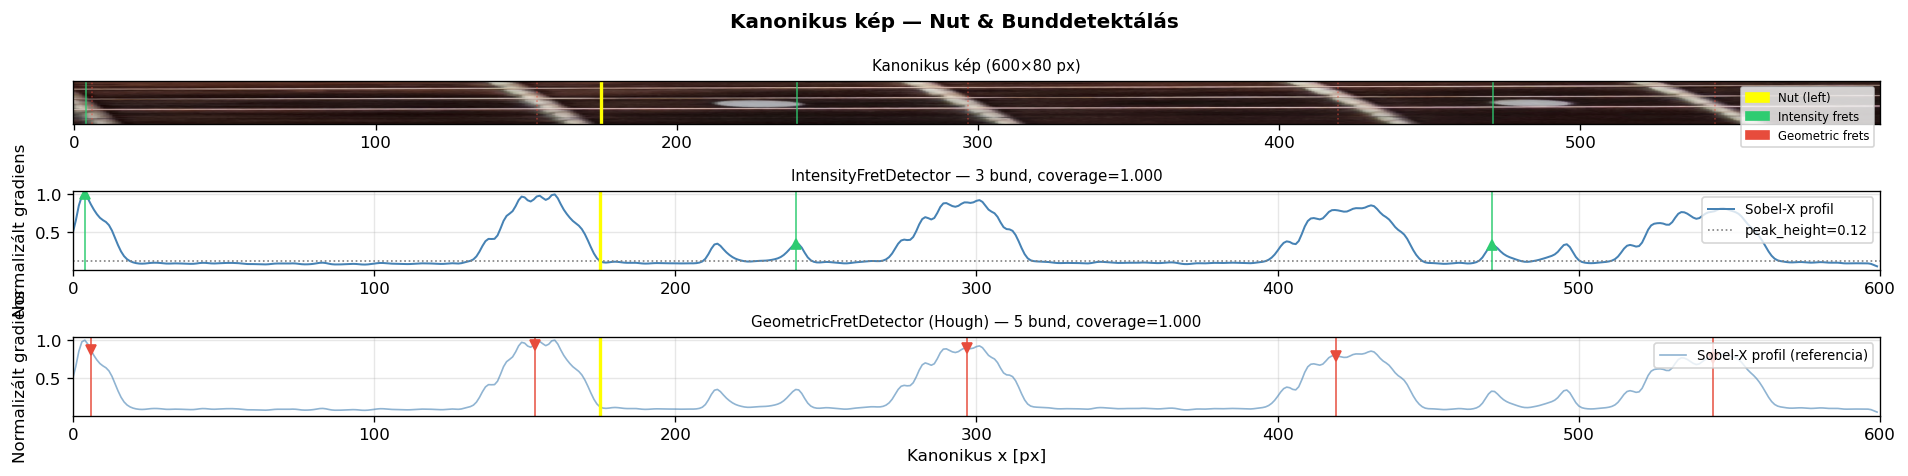

Ábra: ../output/08_detection_sandbox/02_intensity_profile_frets.png


In [16]:
# ══════════════════════════════════════════════════════════════════
#  Intenzitás-profil + Nut + Bundok vizualizáció
# ══════════════════════════════════════════════════════════════════

if res_mp.get("canon") is None:
    print("Nincs kanonikus kép, a cella kihagyva.")
else:
    canon  = res_mp["canon"]
    nut    = res_mp.get("nut")
    xs     = np.arange(len(profile))

    fig, axes = plt.subplots(3, 1, figsize=FIG_WIDE, dpi=FIG_DPI,
                             gridspec_kw={"height_ratios": [1.2, 2.2, 2.2]})
    fig.suptitle("Kanonikus kép — Nut & Bunddetektálás", fontsize=12, fontweight="bold")

    # ─── Panel 0: kanonikus kép ───────────────────────────────────
    ax0 = axes[0]
    ax0.imshow(bgr2rgb(canon), aspect="auto")
    ax0.set_title("Kanonikus kép (600×80 px)", fontsize=9)
    ax0.set_yticks([])

    # Nut vonal a kanonikus képen
    if nut is not None:
        ax0.axvline(x=nut["nut_x"], color="yellow", linewidth=2, linestyle="-",
                    label=f"Nut @ x={nut['nut_x']}")
    # Intensity bund vonalak
    for fx in det_intensity.get("fret_xs_filt", []):
        ax0.axvline(x=fx, color="#2ecc71", linewidth=1, alpha=0.8)
    # Geometric bund vonalak
    for fx in det_geometric.get("fret_xs_filt", []):
        ax0.axvline(x=fx, color="#e74c3c", linewidth=1, alpha=0.5, linestyle=":")

    patches = []
    if nut:
        patches.append(mpatches.Patch(color="yellow",   label=f"Nut ({nut['side']})"))
    patches.append(mpatches.Patch(color="#2ecc71", label="Intensity frets"))
    patches.append(mpatches.Patch(color="#e74c3c", label="Geometric frets"))
    ax0.legend(handles=patches, loc="upper right", fontsize=7)

    # ─── Panel 1: Intensity detektor profil ──────────────────────
    ax1 = axes[1]
    ax1.plot(xs, profile, color="steelblue", linewidth=1.2, label="Sobel-X profil")
    ax1.axhline(y=PEAK_HEIGHT, color="gray", linestyle=":", linewidth=1,
                label=f"peak_height={PEAK_HEIGHT}")

    for fx in det_intensity.get("fret_xs_filt", []):
        ax1.axvline(x=fx, color="#2ecc71", linewidth=1, alpha=0.9)
        ax1.plot(fx, float(profile[int(fx)]) if int(fx) < len(profile) else 0,
                 "^", color="#2ecc71", markersize=6)
    if nut is not None:
        ax1.axvline(x=nut["nut_x"], color="yellow", linewidth=2, linestyle="-")

    removed = det_intensity.get("removed_pairs", [])
    for p1, p2 in removed:
        ax1.axvspan(p1, p2, alpha=0.15, color="red")

    ax1.set_ylabel("Normalizált gradiens")
    ax1.set_title(
        f"IntensityFretDetector — {len(det_intensity.get('fret_xs_filt', []))} bund, "
        f"coverage={det_intensity['fit'].get('coverage_ratio', 0):.3f}",
        fontsize=9)
    ax1.legend(fontsize=8, loc="upper right")
    ax1.grid(alpha=0.3)
    ax1.set_xlim(0, canon.shape[1])

    # ─── Panel 2: Geometric detektor profil (Sobel profil + Hough bundok) ─
    ax2 = axes[2]
    ax2.plot(xs, profile, color="steelblue", linewidth=1.0, alpha=0.6,
             label="Sobel-X profil (referencia)")

    for fx in det_geometric.get("fret_xs_filt", []):
        ax2.axvline(x=fx, color="#e74c3c", linewidth=1, alpha=0.9)
        ax2.plot(fx, float(profile[int(fx)]) if int(fx) < len(profile) else 0,
                 "v", color="#e74c3c", markersize=6)
    if nut is not None:
        ax2.axvline(x=nut["nut_x"], color="yellow", linewidth=2, linestyle="-")

    ax2.set_xlabel("Kanonikus x [px]")
    ax2.set_ylabel("Normalizált gradiens")
    ax2.set_title(
        f"GeometricFretDetector (Hough) — {len(det_geometric.get('fret_xs_filt', []))} bund, "
        f"coverage={det_geometric['fit'].get('coverage_ratio', 0):.3f}",
        fontsize=9)
    ax2.legend(fontsize=8, loc="upper right")
    ax2.grid(alpha=0.3)
    ax2.set_xlim(0, canon.shape[1])

    plt.tight_layout()
    fig_path = OUTPUT_DIR / "02_intensity_profile_frets.png"
    fig.savefig(fig_path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"Ábra: {fig_path}")

---

## 3. Interaktív Nut Vizualizáció

Kinagyítva csak a Nut közvetlen környéke (a kanonikus kép bal/jobb 30%-a).
Az intenzitás-görbe és a detektált peak jól látható — összehasonlítható,
hogy a Nut-csúcs szélességileg (FWHM) valóban különbözik-e a bundoktól.

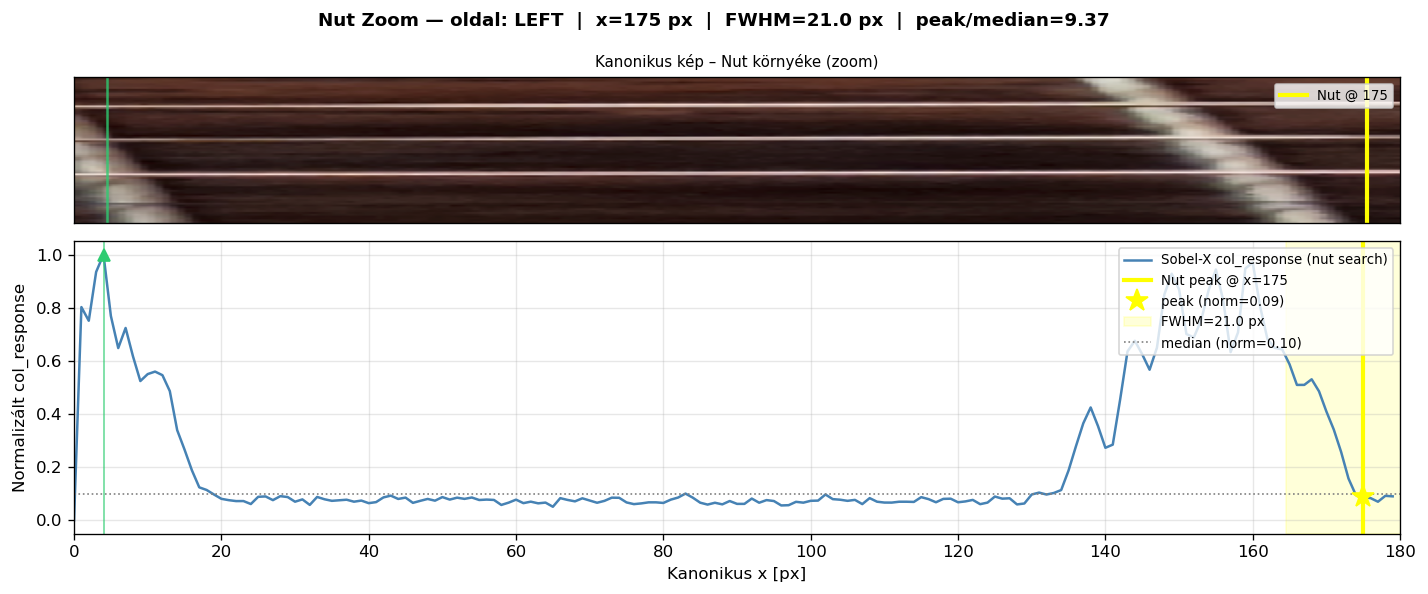

Ábra: ../output/08_detection_sandbox/03_nut_zoom.png

Nut összefoglaló:
  oldal   : left
  x       : 175 px (kanonikus)
  FWHM    : 21.0 px  (bund-jelöltek általában < 5 px)
  ratio   : 9.37×  (median felett)


In [17]:
# ══════════════════════════════════════════════════════════════════
#  Nut zoom vizualizáció
# ══════════════════════════════════════════════════════════════════

NUT_ZOOM_FRAC = 0.30    # kanonikus kép mekkora törtrészét mutassuk

if res_mp.get("canon") is None or res_mp.get("nut") is None:
    print("Nincs kanonikus kép vagy nut — a cella kihagyva.")
else:
    canon   = res_mp["canon"]
    nut     = res_mp["nut"]
    nut_x   = int(nut["nut_x"])
    side    = nut["side"]
    cw      = canon.shape[1]   # 600
    zoom_w  = int(cw * NUT_ZOOM_FRAC)

    # Zoom régió határozása
    if side == "left":
        x0, x1 = 0, zoom_w
    else:
        x0, x1 = cw - zoom_w, cw

    canon_zoom  = canon[:, x0:x1]
    profile_zoom = profile[x0:x1]
    xs_zoom     = np.arange(x0, x1)

    # Nut Sobel profil (pontosan az, amit step6b_find_nut lát)
    gray_canon  = cv2.cvtColor(canon, cv2.COLOR_BGR2GRAY).astype(np.float32)
    sx_canon    = cv2.Sobel(gray_canon, cv2.CV_32F, 1, 0, ksize=3)
    col_resp    = np.abs(sx_canon).sum(axis=0)    # raw (nem normalizált)
    col_resp_zoom = col_resp[x0:x1]
    col_resp_norm = col_resp_zoom / (col_resp_zoom.max() + 1e-6)

    # FWHM mérés a Nut csúcsán
    nut_fwhm  = nut.get("width_px", float("nan"))
    nut_peak  = nut.get("peak", 0.0)
    nut_ratio = nut.get("ratio", 0.0)

    # ── Ábra ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=FIG_NUT_ZOOM, dpi=FIG_DPI,
                             gridspec_kw={"height_ratios": [1, 2]})
    fig.suptitle(
        f"Nut Zoom — oldal: {side.upper()}  |  x={nut_x} px  |  "
        f"FWHM={nut_fwhm:.1f} px  |  peak/median={nut_ratio:.2f}",
        fontsize=11, fontweight="bold"
    )

    # ─── Felső: zoom crop ──────────────────────────────────────
    ax0 = axes[0]
    ax0.imshow(bgr2rgb(canon_zoom), aspect="auto")
    ax0.axvline(x=nut_x - x0, color="yellow", linewidth=2.5,
                label=f"Nut @ {nut_x}")

    # Bundok a zoom régiójában
    for fx in det_intensity.get("fret_xs_filt", []):
        if x0 <= fx <= x1:
            ax0.axvline(x=fx - x0, color="#2ecc71", linewidth=1.5, alpha=0.8)

    ax0.set_title("Kanonikus kép – Nut környéke (zoom)", fontsize=9)
    ax0.set_yticks([])
    ax0.set_xticks([])
    ax0.legend(loc="upper right", fontsize=8)

    # ─── Alsó: intenzitás görbe + peak ───────────────────────────
    ax1 = axes[1]
    ax1.plot(xs_zoom, col_resp_norm, color="steelblue", linewidth=1.5,
             label="Sobel-X col_response (nut search)")
    ax1.axvline(x=nut_x, color="yellow", linewidth=2.5,
                linestyle="-", label=f"Nut peak @ x={nut_x}")

    # Peak marker
    peak_val_norm = float(col_resp_norm[nut_x - x0]) if 0 <= nut_x - x0 < len(col_resp_norm) else 0
    ax1.plot(nut_x, peak_val_norm, "*", color="yellow",
             markersize=14, zorder=5, label=f"peak (norm={peak_val_norm:.2f})")

    # FWHM sáv
    if not np.isnan(nut_fwhm):
        hw = nut_fwhm / 2.0
        ax1.axvspan(nut_x - hw, nut_x + hw, alpha=0.15, color="yellow",
                    label=f"FWHM={nut_fwhm:.1f} px")

    # Median vonal
    median_resp = float(np.median(col_resp))
    median_norm = median_resp / (col_resp_zoom.max() + 1e-6)
    ax1.axhline(y=median_norm, color="gray", linestyle=":", linewidth=1,
                label=f"median (norm={median_norm:.2f})")

    # Közelben lévő bund csúcsok jelölése
    for fx in det_intensity.get("fret_xs_filt", []):
        if x0 <= fx <= x1:
            fv = float(profile[int(fx)])
            ax1.axvline(x=fx, color="#2ecc71", linewidth=1, alpha=0.7)
            ax1.plot(fx, fv, "^", color="#2ecc71", markersize=7)

    ax1.set_xlabel("Kanonikus x [px]")
    ax1.set_ylabel("Normalizált col_response")
    ax1.set_xlim(x0, x1)
    ax1.legend(fontsize=8, loc="upper left" if side == "right" else "upper right")
    ax1.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = OUTPUT_DIR / "03_nut_zoom.png"
    fig.savefig(fig_path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"Ábra: {fig_path}")
    print()
    print(f"Nut összefoglaló:")
    print(f"  oldal   : {side}")
    print(f"  x       : {nut_x} px (kanonikus)")
    print(f"  FWHM    : {nut_fwhm:.1f} px  (bund-jelöltek általában < {5} px)")
    print(f"  ratio   : {nut_ratio:.2f}×  (median felett)")

---

## 4. Intensity-based ROI részletező

A sor-projekciós módszer belső állapotának vizualizációja:
melyik sorokat érzékeli "aktívnak" (magas horizontális gradiens),
és hogyan határozódik meg a crop sáv.

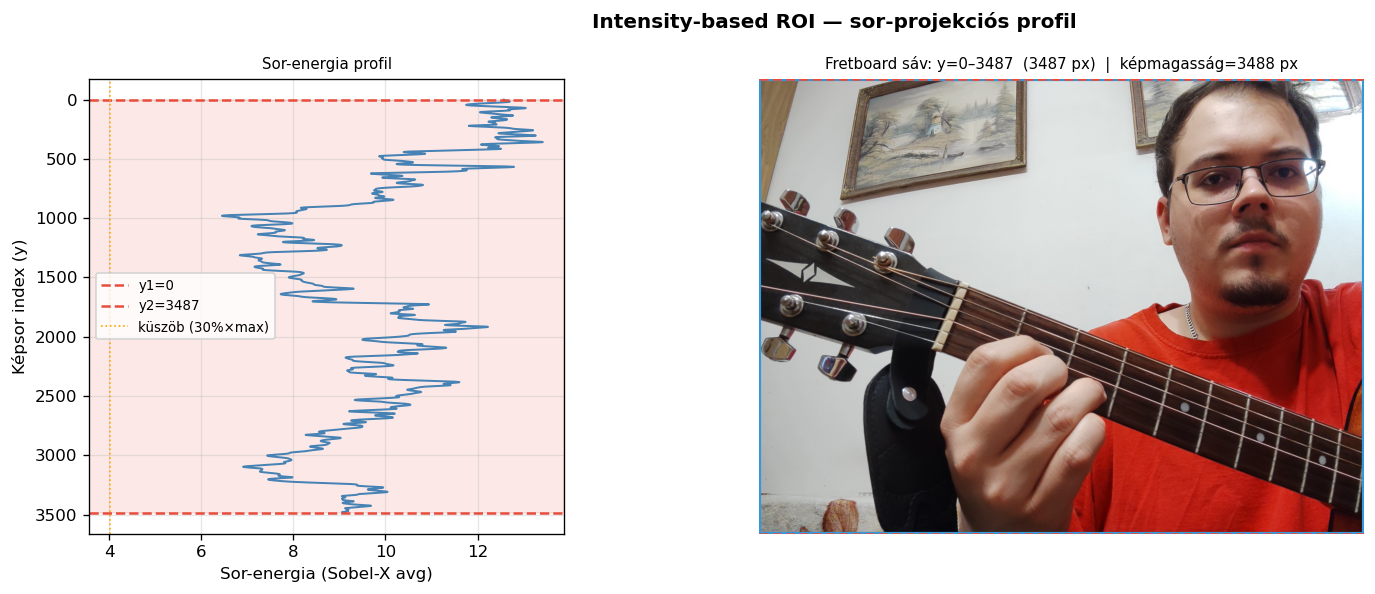

Ábra: ../output/08_detection_sandbox/04_intensity_roi_profile.png
  Crop sáv: y=0..3487  (100.0% a képmagasságból)
  Kanonikus méret (stretched): 600×80 px


In [18]:
# ══════════════════════════════════════════════════════════════════
#  Intensity-based ROI belső profil vizualizáció
# ══════════════════════════════════════════════════════════════════

ROI_ROW_FRAC   = 0.3    # azonos az roi_intensity_based() alapértelmezésével
ROI_SMOOTH_SIGMA = 5.0

if res_int is None:
    print("Intensity-based ROI sikertelen — cella kihagyva.")
else:
    row_energy = res_int["row_energy"]
    y1, y2     = res_int["y1"], res_int["y2"]
    h, w       = img_bgr.shape[:2]

    threshold = row_energy.max() * ROI_ROW_FRAC
    row_idx   = np.arange(len(row_energy))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI,
                             gridspec_kw={"width_ratios": [1, 2.5]})
    fig.suptitle("Intensity-based ROI — sor-projekciós profil", fontsize=12,
                 fontweight="bold")

    # ─── Bal panel: sor-energia profil (vízszintesen, y tengelyen) ─
    ax0 = axes[0]
    ax0.plot(row_energy, row_idx, color="steelblue", linewidth=1.2)
    ax0.axhline(y=y1, color="#e74c3c", linewidth=1.5, linestyle="--",
                label=f"y1={y1}")
    ax0.axhline(y=y2, color="#e74c3c", linewidth=1.5, linestyle="--",
                label=f"y2={y2}")
    ax0.axvline(x=threshold, color="orange", linewidth=1, linestyle=":",
                label=f"küszöb ({ROI_ROW_FRAC*100:.0f}%×max)")
    ax0.axhspan(y1, y2, alpha=0.12, color="#e74c3c")
    ax0.invert_yaxis()
    ax0.set_xlabel("Sor-energia (Sobel-X avg)")
    ax0.set_ylabel("Képsor index (y)")
    ax0.set_title("Sor-energia profil", fontsize=9)
    ax0.legend(fontsize=8)
    ax0.grid(alpha=0.3)

    # ─── Jobb panel: eredeti kép + crop overlay ────────────────────
    ax1 = axes[1]
    ax1.imshow(bgr2rgb(img_bgr))
    rect = plt.Rectangle((0, y1), w, y2 - y1,
                          fill=False, edgecolor="#3498db", linewidth=2.5)
    ax1.add_patch(rect)
    ax1.axhline(y=y1, color="#e74c3c", linewidth=1.5, linestyle="--")
    ax1.axhline(y=y2, color="#e74c3c", linewidth=1.5, linestyle="--")
    ax1.set_title(
        f"Fretboard sáv: y={y1}–{y2}  ({y2 - y1} px)  |  "
        f"képmagasság={h} px",
        fontsize=9)
    ax1.axis("off")

    plt.tight_layout()
    fig_path = OUTPUT_DIR / "04_intensity_roi_profile.png"
    fig.savefig(fig_path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"Ábra: {fig_path}")
    print(f"  Crop sáv: y={y1}..{y2}  ({((y2-y1)/h*100):.1f}% a képmagasságból)")
    print(f"  Kanonikus méret (stretched): {res_int['canon'].shape[1]}×{res_int['canon'].shape[0]} px")

---

## Összefoglalás

| Komponens | Hol fut? | Mi a bemenet? | Mi a kimenet? |
|---|---|---|---|
| Preprocessing | Eredeti kép | BGR kép | Kontrasztjavított BGR kép |
| MediaPipe | Eredeti kép (raw!) | BGR kép | Landmark koordináták |
| Finger mask | Eredeti kép | Landmarks | Bináris maszk |
| ROI (Hough+warp) | Preprocessed kép | Edges + lines | Kanonikus kép (600×80) |
| Nut detect | Kanonikus kép | col_response | nut_x, side, FWHM |
| Nut trim | Eredeti kép | nut_x + H_inv | Új trapézoid sarokpontok |
| Re-warp | Eredeti kép | Új sarokpontok | Végső kanonikus kép |
| Fret detect | Végső kanonikus | Sobel/Hough | fret_xs, fit |

A **Nut mindig a ROI után, de a végső warp ELŐTT** kerül detektálásra:
az első warp ad egy "durva" kanonikus képet a Nut kereséshez,
majd a Nut pozíciója finomítja a trapézoidot, és egy második warp
adja a végleges, Nut-igazított kanonikus képet.

---

## 5. Diagnosztikai Galéria — Vertikális Batch Vizualizáció

Minden tesztkép egy **1×4-es diagnosztikai sort** kap, egymás alatt görgethetően.

| Oszlop | Tartalom |
|---|---|
| **Original ROI** | A warped kanonikus kép (600×80 px) |
| **Nut Focus** | Bal/jobb ~33% → ~300%-os zoom, sárga Nut-vonal |
| **Signal Analysis** | Sobel-X profil, Nut ★ (arany), Fret ▲ (zöld) |
| **Final Detection** | Teljes ROI + összes detektált vonal |

Ha a Nut nem található, a „Nut Focus" cellában **piros figyelmeztetés** jelenik meg,
de a loop folytatódik a következő képpel.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  GALÉRIA KONFIGURÁCIÓ
# ══════════════════════════════════════════════════════════════════

GALLERY_FIGSIZE          = (18, 5)    # fix széles formátum
GALLERY_NUT_ZOOM_FRAC    = 0.33       # kanonikus kép ~1/3-a → ~3× zoom
GALLERY_SAMPLE_PER_CLASS = 1          # ennyi képet veszünk osztályonként
GALLERY_MAX_IMAGES       = 8          # kemény felső korlát (None = összes)
GALLERY_RANDOM_STATE     = 42

print(f"Galéria beállítások:")
print(f"  figsize          = {GALLERY_FIGSIZE}")
print(f"  nut_zoom_frac    = {GALLERY_NUT_ZOOM_FRAC}  (~{1/GALLERY_NUT_ZOOM_FRAC:.0f}× zoom)")
print(f"  sample_per_class = {GALLERY_SAMPLE_PER_CLASS}")
print(f"  max_images       = {GALLERY_MAX_IMAGES}")

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  plot_diagnostic_row() — egy tesztkép → 1×4 diagnosztikai sor
# ══════════════════════════════════════════════════════════════════
import contextlib, io

def plot_diagnostic_row(img_path, cls_label, preprocessor=None, verbose=False):
    """Egy képhez 1×4 diagnosztikai sort rajzol és visszaadja a figure-t.

    Columns:
      0 - Original ROI      (kanonikus 600×80 px, vagy az eredeti kép ha FAIL)
      1 - Nut Focus         (bal/jobb ~33% crop ≈ 300% zoom + Nut vonal)
      2 - Signal Analysis   (1D Sobel-X profil, Nut★ + Fret▲ jelölve)
      3 - Final Detection   (teljes ROI + Nut sárga + Fret zöld vonalak)

    verbose=False: elnémítja a pipeline belső debug-printjeit ([outer_edges_v9], stb.)
    """
    from pathlib import Path

    img_name = Path(img_path).name
    img_bgr  = load_image_bgr(img_path)

    # ── Pipeline — verbose mód szerint stdout elnyomással ─────────
    entry = {"path": img_path, "class": cls_label}
    _sink = io.StringIO()
    with contextlib.redirect_stdout(None if verbose else _sink):
        res = run_v14_pipeline(entry, preprocessor=preprocessor)

    pipeline_ok = res.get("ok", False)
    canon  = res.get("canon")
    nut    = res.get("nut")
    reason = res.get("invalid_reason", "")

    det     = None
    profile = None
    if pipeline_ok and canon is not None:
        det     = intensity_det.detect(canon, nut=nut)
        profile = intensity_det.gradient_profile(canon)

    fret_xs    = det["fret_xs_filt"] if det else []
    fret_count = len(fret_xs)
    nut_x      = int(nut["nut_x"]) if nut else None
    nut_side   = nut.get("side", "?") if nut else "?"
    nut_width  = nut.get("width_px", float("nan")) if nut else float("nan")

    # ── Figure ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=GALLERY_FIGSIZE, dpi=FIG_DPI)

    if pipeline_ok:
        nut_str = (f"Nut: x={nut_x}px  FWHM={nut_width:.1f}px"
                   if nut else "Nut: NOT detected")
        title_color = "white"
    else:
        nut_str = f"FAIL: {reason}"
        title_color = "tomato"

    fig.suptitle(
        f"[{cls_label}]  {img_name}   —   {nut_str}   |   Frets: {fret_count}",
        fontsize=10, fontweight="bold", y=1.02, color=title_color,
    )

    # ─── Col 0: Original ROI (vagy eredeti kép, ha fail) ──────────
    ax0 = axes[0]
    if canon is not None:
        ax0.imshow(bgr2rgb(canon), aspect="auto")
        ax0.set_title("Original ROI\n(600×80 px canonical)", fontsize=8)
    else:
        # Sikertelen pipeline → eredeti képet mutatjuk magyarázattal
        ax0.imshow(bgr2rgb(img_bgr), aspect="auto")
        short_reason = reason.replace("trapezoid_sanity: ", "")
        ax0.text(0.5, 0.02, short_reason,
                 transform=ax0.transAxes, ha="center", va="bottom",
                 color="tomato", fontsize=7, fontweight="bold",
                 bbox=dict(facecolor="black", alpha=0.70, pad=3))
        ax0.set_title("Original image\n(pipeline FAILED)", fontsize=8, color="tomato")
    ax0.axis("off")

    # ─── Col 1: Nut Focus Zoom (~300%) ────────────────────────────
    ax1 = axes[1]
    if canon is not None:
        cw     = canon.shape[1]
        zoom_w = int(cw * GALLERY_NUT_ZOOM_FRAC)
        x0z    = 0           if nut_side == "left"  else cw - zoom_w
        x1z    = zoom_w      if nut_side == "left"  else cw
        zoom_crop = canon[:, x0z:x1z]
        ax1.imshow(bgr2rgb(zoom_crop), aspect="auto")

        if nut_x is not None:
            ax1.axvline(x=nut_x - x0z, color="yellow", linewidth=2.5)
            ax1.set_title(
                f"Nut Focus (~300% zoom)\n{nut_side.upper()}  x={nut_x}px  FWHM={nut_width:.1f}px",
                fontsize=8)
        else:
            ax1.text(0.5, 0.5, "Nut NOT\ndetected",
                     transform=ax1.transAxes, ha="center", va="center",
                     color="red", fontsize=12, fontweight="bold",
                     bbox=dict(facecolor="black", alpha=0.65, pad=4))
            ax1.set_title("Nut Focus (~300% zoom)\n—", fontsize=8)
    else:
        ax1.set_facecolor("#111111")
        ax1.text(0.5, 0.5, "—", transform=ax1.transAxes,
                 ha="center", va="center", color="#555555", fontsize=18)
        ax1.set_title("Nut Focus (~300% zoom)", fontsize=8)
    ax1.axis("off")

    # ─── Col 2: Signal Analysis ────────────────────────────────────
    ax2 = axes[2]
    if profile is not None:
        xs = np.arange(len(profile))
        ax2.plot(xs, profile, color="steelblue", linewidth=1.1,
                 label="Sobel-X profil", alpha=0.85)
        ax2.axhline(y=PEAK_HEIGHT, color="#888888", linestyle=":",
                    linewidth=0.9, label=f"height={PEAK_HEIGHT}")

        # Nut peak  ★
        if nut_x is not None:
            nv = float(profile[min(nut_x, len(profile) - 1)])
            ax2.axvline(x=nut_x, color="gold", linewidth=1.8, linestyle="-")
            ax2.plot(nut_x, nv, "*", color="gold", markersize=13, zorder=6,
                     label=f"Nut ★ x={nut_x}")

        # Fret peaks  ▲
        for i, fx in enumerate(fret_xs):
            fv = float(profile[min(int(fx), len(profile) - 1)])
            ax2.axvline(x=fx, color="#2ecc71", linewidth=0.9, alpha=0.8)
            ax2.plot(fx, fv, "^", color="#2ecc71", markersize=7, zorder=5,
                     label="Fret ▲" if i == 0 else "")

        ax2.set_xlim(0, len(profile))
        ax2.set_ylim(bottom=0)
        ax2.set_title(f"Signal Analysis\n{fret_count} fret | peak_h={PEAK_HEIGHT}", fontsize=8)
        ax2.set_xlabel("Kanonikus x [px]", fontsize=7)
        ax2.set_ylabel("Norm. gradiens", fontsize=7)
        ax2.tick_params(labelsize=6)
        ax2.legend(fontsize=6, loc="upper right", framealpha=0.7)
        ax2.grid(alpha=0.25)
    else:
        ax2.set_facecolor("#0d0d0d")
        ax2.text(0.5, 0.5, "—", transform=ax2.transAxes,
                 ha="center", va="center", color="#555555", fontsize=18)
        ax2.set_title("Signal Analysis", fontsize=8)

    # ─── Col 3: Final Detection ────────────────────────────────────
    ax3 = axes[3]
    if canon is not None:
        ax3.imshow(bgr2rgb(canon), aspect="auto")
        if nut_x is not None:
            ax3.axvline(x=nut_x, color="yellow", linewidth=2.5, label="Nut")
        for i, fx in enumerate(fret_xs):
            ax3.axvline(x=fx, color="#2ecc71", linewidth=1.5, alpha=0.9,
                        label="Frets" if i == 0 else "")
        if nut_x is not None or fret_xs:
            ax3.legend(fontsize=7, loc="upper right", framealpha=0.75)
        ax3.set_title(f"Final Detection\nNut + {fret_count} fret", fontsize=8)
    else:
        ax3.set_facecolor("#111111")
        ax3.text(0.5, 0.5, "—", transform=ax3.transAxes,
                 ha="center", va="center", color="#555555", fontsize=18)
        ax3.set_title("Final Detection", fontsize=8)
    ax3.axis("off")

    plt.tight_layout()
    return fig, pipeline_ok, reason

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  GALÉRIA LOOP — végigmegy a kiválasztott képeken
# ══════════════════════════════════════════════════════════════════
import pandas as pd
from collections import Counter

gallery_manifest = load_manifest()

# Teszt-split szűrése, ha van "split" oszlop
if "split" in gallery_manifest.columns:
    gallery_manifest = gallery_manifest[gallery_manifest["split"] == "test"].copy()

# 1 kép osztályonként
if GALLERY_SAMPLE_PER_CLASS is not None:
    frames = []
    for cls, grp in gallery_manifest.groupby("class"):
        n = min(GALLERY_SAMPLE_PER_CLASS, len(grp))
        frames.append(grp.sample(n, random_state=GALLERY_RANDOM_STATE))
    gallery_manifest = pd.concat(frames).reset_index(drop=True)

if GALLERY_MAX_IMAGES is not None:
    gallery_manifest = gallery_manifest.head(GALLERY_MAX_IMAGES)

print(f"Galéria: {len(gallery_manifest)} kép feldolgozása  [verbose=False → nincs debug print]")
print("-" * 60)

fail_log = []

for idx, row in gallery_manifest.iterrows():
    fig, ok, reason = plot_diagnostic_row(
        img_path=row["path"],
        cls_label=row["class"],
        preprocessor=prep,
        verbose=False,          # True → visszakapod a [outer_edges_v9] stb. printeket
    )
    plt.show()
    if not ok:
        fail_log.append((row["class"], row["path"].name, reason))

# ── Összefoglaló ──────────────────────────────────────────────────
total = len(gallery_manifest)
n_ok  = total - len(fail_log)
print(f"\n{'─'*60}")
print(f"Összefoglaló: {n_ok}/{total} sikeres  ({100*n_ok/total:.0f}%)")
if fail_log:
    print(f"\nSikertelen képek ({len(fail_log)} db):")
    reason_counts = Counter(r for _, _, r in fail_log)
    for reason, cnt in reason_counts.most_common():
        print(f"  [{cnt}×]  {reason}")
    for cls, fname, r in fail_log:
        print(f"    [{cls}] {fname}  →  {r}")

---

## 6. Nut-First Diagnosztika — Trapézoid Kiterjesztés

Ez a szekció a **Nut-First stratégia** hatását mutatja be:
- a tág (kezet is magában foglaló) trapézoidot
- az intenzitás-profilt a teljes tág kanonikus képen
- a sikeresen azonosított Nut-ot (akkor is, ha kéz van a Nut közelében)

| Sor | Tartalom |
|---|---|
| **Plot 1** | Eredeti kép + tág trapézoid sarkok (cyan) + kéz-landmark overlay (piros) |
| **Plot 2** | Sobel-x col_response a tág kanonikus képen; Nut jelölt (piros X), FWHM annotáció |
| **Plot 3** | Tág canon kép + Nut vonal → trim utáni re-warp egymás mellett |


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  6. NUT-FIRST DIAGNOSZTIKA — Trapézoid kiterjesztés vizualizáció
# ══════════════════════════════════════════════════════════════════
import importlib, src.geometry, src.fretboard, src.config
importlib.reload(src.geometry)
importlib.reload(src.fretboard)
importlib.reload(src.config)

from src.config import CFG
from src.geometry import (
    load_image_bgr, bgr2rgb,
    step1_canny, step2_hough, step3_neck_angle, step4_split_lines,
    step5_outer_edges, step6_clamp_trapezoid_extent, step6_trapezoid,
    step6_warp, step6b_find_nut,
)
from src.hand_landmark import (
    step9_detect_landmarks, build_finger_mask,
    anchor_neck_angle, step3_neck_angle_anchored,
    get_fretboard_near_edge,
)
from src.fretboard import _choose_nut_side, _project_landmark_to_canon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, cv2
from scipy.signal import find_peaks

# ── CFG override: Nut-First BE ──────────────────────────────────────────
CFG['nut_extend_amin_enabled'] = True
CFG['nut_extend_amin_margin_px'] = 40

LANDMARK_COLORS = [
    (255,  48,  48),  # csukló (0) — piros
    (255, 165,   0),  # hüvelykujj — narancs
    (255, 255,   0),  # mutató — sárga
    (  0, 220,   0),  # középső — zöld
    (  0, 180, 255),  # gyűrűs — kék
    (180,   0, 255),  # kisujj — lila
]
FINGER_GROUPS = [[0], [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20]]


def _draw_landmarks_on(img_rgb, landmarks, img_shape):
    """Landmark pontok + csontvázrajz az img_rgb-re (in-place másolaton)."""
    out = img_rgb.copy()
    if landmarks is None:
        return out
    h, w = img_shape[:2]
    pts = [(int(lx * w), int(ly * h)) for (lx, ly, _) in landmarks]
    connections = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (0,9),(9,10),(10,11),(11,12),
        (0,13),(13,14),(14,15),(15,16),
        (0,17),(17,18),(18,19),(19,20),
        (5,9),(9,13),(13,17),
    ]
    for a, b in connections:
        cv2.line(out, pts[a], pts[b], (220, 220, 220), 1, cv2.LINE_AA)
    for grp_i, grp in enumerate(FINGER_GROUPS):
        c = LANDMARK_COLORS[grp_i]
        for idx in grp:
            if idx < len(pts):
                cv2.circle(out, pts[idx], 4, c, -1)
    return out


def _draw_trapezoid_on(img_rgb, corners_px, color=(0, 255, 255), thickness=2):
    out = img_rgb.copy()
    pts = corners_px.astype(int)
    for i in range(4):
        cv2.line(out, tuple(pts[i]), tuple(pts[(i+1)%4]), color, thickness, cv2.LINE_AA)
    for pt in pts:
        cv2.circle(out, tuple(pt), 5, color, -1)
    return out


def plot_nut_first_diagnostic(img_path, landmarker, fig_dpi=FIG_DPI):
    """3 vertikális plot: tág trapézoid | intenzitás-profil | Nut azonosítás."""
    img = load_image_bgr(str(img_path))
    landmarks = step9_detect_landmarks(str(img_path), landmarker)
    anchor = anchor_neck_angle(landmarks, img.shape)
    finger_mask = build_finger_mask(img.shape, landmarks)

    edges = step1_canny(img)
    edges_masked = edges.copy()
    if finger_mask.any():
        edges_masked[finger_mask > 0] = 0

    lines = step2_hough(img, edges_masked)
    if not lines:
        print(f'  SKIP {img_path.name}: no Hough lines')
        return

    neck_plain = step3_neck_angle(lines)
    split_plain = step4_split_lines(lines, neck_plain['angle_deg'])
    if len(split_plain['long_lines']) >= 3 or anchor is None:
        neck, split = neck_plain, split_plain
    else:
        neck_anc = step3_neck_angle_anchored(lines, anchor=anchor)
        split_anc = step4_split_lines(lines, neck_anc['angle_deg'])
        if len(split_anc['long_lines']) > len(split_plain['long_lines']):
            neck, split = neck_anc, split_anc
        else:
            neck, split = neck_plain, split_plain

    if not split['long_lines']:
        print(f'  SKIP {img_path.name}: no long lines')
        return

    edge_info = step5_outer_edges(split['long_lines'], neck['angle_deg'])
    if edge_info is None:
        print(f'  SKIP {img_path.name}: no outer edges')
        return
    edge_info = step6_clamp_trapezoid_extent(edge_info, anchor)

    # Tág trapézoid (landmarks = kéz beleesik)
    trap = step6_trapezoid(img, edge_info, landmarks=landmarks)
    if trap is None:
        print(f'  SKIP {img_path.name}: no trapezoid')
        return

    H, H_inv, canon = step6_warp(img, trap['corners_px'])

    # Nut keresés a tág kanonikus képen
    side_hint = _choose_nut_side(anchor, H, img.shape)
    hand_bnd_x = None
    near_edge = get_fretboard_near_edge(landmarks, img.shape)
    if near_edge is not None:
        hand_bnd_x = _project_landmark_to_canon(near_edge, H)

    nut = step6b_find_nut(canon, side_hint=side_hint,
                          hand_boundary_canon_x=hand_bnd_x)

    # ── Sobel-x profil ──────────────────────────────────────────────────────
    gray = cv2.cvtColor(canon, cv2.COLOR_BGR2GRAY)
    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    col_response = np.abs(sx).sum(axis=0).astype(np.float32)
    col_norm = col_response / (col_response.max() + 1e-6)

    # ── Plot ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), dpi=fig_dpi)
    fig.suptitle(f'Nut-First Diagnosztika: {img_path.name}', fontsize=11, y=1.01)

    # --- Plot 1: tág trapézoid + landmark overlay ---
    ax1 = axes[0]
    vis = bgr2rgb(img.copy())
    vis = _draw_landmarks_on(vis, landmarks, img.shape)
    vis = _draw_trapezoid_on(vis, trap['corners_px'], color=(0, 220, 220), thickness=2)
    ax1.imshow(vis)
    ax1.set_title('1. Tág trapézoid (kezet is tartalmaz) + landmark csontváz', fontsize=9)
    ax1.axis('off')
    ax1.legend(handles=[
        mpatches.Patch(color='cyan', label='Trapézoid sarkok'),
        mpatches.Patch(color='red',  label='Landmark pontok'),
    ], fontsize=7, loc='upper right')

    # --- Plot 2: Sobel-x intenzitás-profil ---
    ax2 = axes[1]
    xs = np.arange(len(col_norm))
    ax2.plot(xs, col_norm, color='steelblue', linewidth=1.0, label='Sobel-x col_response')

    # Bunddetektált csúcsok (kék)
    peaks, _ = find_peaks(col_norm, height=0.1, distance=7)
    ax2.scatter(peaks, col_norm[peaks], color='royalblue', s=20, zorder=3, label='Csúcsok')

    # hand_bnd_x (sárga szaggatott)
    if hand_bnd_x is not None:
        ax2.axvline(hand_bnd_x, color='gold', linestyle='--', linewidth=1.2,
                    label=f'hand_bnd_x={hand_bnd_x:.0f}px')

    # Nut jelölt (piros X + FWHM annotáció)
    if nut is not None:
        nx = nut['nut_x']
        ax2.axvline(nx, color='tomato', linewidth=1.5, label=f'Nut x={nx}px')
        ax2.scatter([nx], [col_norm[nx]], color='red', marker='x', s=80, zorder=5)
        ax2.annotate(
            f"FWHM={nut['width_px']:.1f}px\nratio={nut['ratio']:.1f}",
            xy=(nx, col_norm[nx]), xytext=(nx + 8, col_norm[nx] + 0.05),
            fontsize=7, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=0.8),
        )
    else:
        ax2.text(0.5, 0.5, 'NUT NEM FOUND', transform=ax2.transAxes,
                 ha='center', va='center', color='red', fontsize=12, alpha=0.7)

    ax2.set_title('2. Sobel-x intenzitás-profil (tág kanonikus kép)', fontsize=9)
    ax2.set_xlabel('x (canon px)', fontsize=8)
    ax2.set_ylabel('norm. válasz', fontsize=8)
    ax2.legend(fontsize=7, loc='upper right')
    ax2.set_xlim(0, canon.shape[1])

    # --- Plot 3: tág canon + Nut vonal | trim utáni re-warp ---
    ax3 = axes[2]
    canon_vis = bgr2rgb(canon.copy())

    if nut is not None:
        from src.geometry import step6c_trim_to_nut
        corners_trim = step6c_trim_to_nut(trap['corners_px'], H_inv, nut)
        _, _, canon2 = step6_warp(img, corners_trim)
        # Tág + vonal | Trim side-by-side
        nut_vis = canon_vis.copy()
        cv2.line(nut_vis, (nut['nut_x'], 0), (nut['nut_x'], nut_vis.shape[0]-1),
                 (0, 220, 0), 2)
        combined = np.concatenate([nut_vis, bgr2rgb(canon2)], axis=1)
        ax3.imshow(combined)
        ax3.axvline(canon_vis.shape[1], color='white', linewidth=1, linestyle=':')
        ax3.set_title(f'3. Tág canon (Nut={nut["nut_x"]}px zöld) | Trim utáni re-warp', fontsize=9)
    else:
        ax3.imshow(canon_vis)
        ax3.set_title('3. Tág canon (NUT NEM TALÁLT — trim nem fut)', fontsize=9)
    ax3.axis('off')

    plt.tight_layout()
    plt.show()


# ── Futtatás ────────────────────────────────────────────────────────────────
print('Nut-First diagnosztika futtatása...')
for img_path in TEST_IMAGES[:6]:   # első 6 teszt kép
    plot_nut_first_diagnostic(img_path, landmarker)
